Ten skrypt w  buduje i ocenia agenta AI, który wykorzystuje modele językowe do interakcji z danymi sprzedażowymi, umożliwiając zadawanie pytań w języku naturalnym, generowanie zapytań SQL, analizę danych oraz tworzenie wizualizacji.

# Setup

In [ ]:
!pip install -q  openai "arize-phoenix>=8.8.0" "arize-phoenix-otel>=0.8.0" openinference-instrumentation-openai duckdb "openinference-instrumentation>=0.1.21"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.2/299.2 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.9/62.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 79.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.1/232.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.0/119.0 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.8/65.

In [ ]:
# Standard library imports
import json
import os
import uuid

# Third-party library imports
import duckdb
import nest_asyncio
import pandas as pd
from IPython.display import Markdown
from openai import OpenAI
from openinference.instrumentation import suppress_tracing
from openinference.instrumentation.openai import OpenAIInstrumentor
from opentelemetry.trace import StatusCode
from pydantic import BaseModel, Field
from tqdm import tqdm

# Google Colab specific imports (often treated as a separate group if platform-specific)
from google.colab import userdata

# Project-specific
import phoenix as px
from phoenix.evals import TOOL_CALLING_PROMPT_TEMPLATE, OpenAIModel, llm_classify
from phoenix.experiments import evaluate_experiment, run_experiment
from phoenix.experiments.evaluators import create_evaluator
from phoenix.experiments.types import Example
from phoenix.otel import register
from phoenix.trace import SpanEvaluations
from phoenix.trace.dsl import SpanQuery

# Apply nest_asyncio immediately after import if needed globally
nest_asyncio.apply()

Ten kod zawiera listę importowanych bibliotek i modułów, które będą używane w programie. Importy są podzielone na kilka sekcji dla lepszej organizacji:

*   **Standard library imports:** Zawiera moduły dostępne domyślnie z instalacją Pythona, takie jak `json` (do pracy z danymi JSON), `os` (do interakcji z systemem operacyjnym), i `uuid` (do generowania unikalnych identyfikatorów).
*   **Third-party library imports:** Zawiera biblioteki zainstalowane za pomocą `pip`, które nie są częścią standardowej biblioteki Pythona. Należą do nich:
    *   `duckdb`: Baza danych w pamięci.
    *   `nest_asyncio`: Pozwala na uruchamianie zagnieżdżonych pętli zdarzeń asynchronicznych, co jest przydatne w środowiskach takich jak Jupyter Notebook.
    *   `pandas`: Biblioteka do analizy i manipulacji danymi, oferująca struktury danych takie jak DataFrame.
    *   `IPython.display.Markdown`: Umożliwia wyświetlanie tekstu sformatowanego jako Markdown w środowisku IPython (np. Jupyter Notebook).
    *   `openai`: Oficjalna biblioteka OpenAI do interakcji z ich modelami językowymi.
    *   `openinference.instrumentation`: Narzędzia do monitorowania i śledzenia działania modeli wnioskowania, szczególnie tych wykorzystujących OpenInference.
    *   `opentelemetry.trace`: Biblioteka do śledzenia rozproszonych transakcji, co pomaga w diagnozowaniu problemów z wydajnością i niezawodnością.
    *   `pydantic`: Biblioteka do walidacji danych i definiowania modeli danych.
    *   `tqdm`: Biblioteka do wyświetlania pasków postępu podczas długotrwałych operacji.
*   **Google Colab specific imports:** Zawiera importy specyficzne dla środowiska Google Colab, takie jak `userdata`, które umożliwiają dostęp do zmiennych zdefiniowanych w ustawieniach Colab.
*   **Project-specific ** Obejmuje to moduł `phoenix` oraz jego różne podmoduły (np. `phoenix.evals`, `phoenix.experiments`, `phoenix.otel`, `phoenix.trace`).

Na końcu znajduje się linia `nest_asyncio.apply()`. Ta funkcja jest wywoływana, aby umożliwić działanie zagnieżdżonych pętli zdarzeń asynchronicznych w środowisku, które domyślnie tego nie obsługuje (np. Jupyter Notebook).

In [ ]:
class CFG:
    model = "gpt-4o-mini"


#  model = "gpt-4.1-nano"

os.environ["PHOENIX_COLLECTOR_ENDPOINT"] = "https://app.phoenix.arize.com"
os.environ["PHOENIX_CLIENT_HEADERS"] = "api_key=" + userdata.get("arize")
os.environ["OPENAI_API_KEY"] = userdata.get("openaivision")
openai_key = userdata.get("openaivision")


In [ ]:
client = OpenAI()
project_name = "talk-to-your-data-agent"

Ten kod inicjalizuje klienta OpenAI oraz definiuje nazwę projektu.

*   **`client = OpenAI()`**: Tworzy instancję klasy `OpenAI`, która reprezentuje klienta API OpenAI. Ta instancja będzie używana do wysyłania zapytań do modeli językowych OpenAI, takich jak GPT-3 lub GPT-4. Domyślnie wykorzystuje klucz API skonfigurowany w zmiennej środowiskowej `OPENAI_API_KEY` (ustawionej wcześniej).

*   **`project_name = "talk-to-your-data-agent"`**: Przypisuje wartość `"talk-to-your-data-agent"` do zmiennej `project_name`. Ta zmienna przechowuje nazwę projektu, która może być używana w raportach, logach lub innych miejscach w kodzie do identyfikacji tego konkretnego zastosowania.

In [ ]:
tracer_provider = register(
    project_name=project_name,
)

OpenAIInstrumentor().instrument(tracer_provider=tracer_provider)

tracer = tracer_provider.get_tracer(__name__)

ERROR:opentelemetry.instrumentation.instrumentor:DependencyConflict: requested: "openai >= 1.69.0" but found: "openai 1.61.1"


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: talk-to-your-data-agent
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: https://app.phoenix.arize.com/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {'api_key': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



Ten kod konfiguruje śledzenie rozproszone (distributed tracing) za pomocą biblioteki OpenTelemetry i integruje je z klientem OpenAI. Śledzenie rozproszone pozwala na monitorowanie przepływu żądań przez różne komponenty systemu, co ułatwia diagnozowanie problemów z wydajnością i niezawodnością.

*   **`tracer_provider = register(project_name=project_name)`**: Wywołuje funkcję `register` (z modułu `phoenix.otel`) w celu zainicjowania dostawcy śledzenia OpenTelemetry. Funkcja ta konfiguruje podstawowe ustawienia śledzenia, takie jak nazwa projektu (`project_name`), i zwraca obiekt `tracer_provider`, który zarządza śladami.

*   **`OpenAIInstrumentor().instrument(tracer_provider=tracer_provider)`**: Tworzy instancję klasy `OpenAIInstrumentor` (z modułu `openinference.instrumentation.openai`) i wywołuje jej metodę `instrument`. Ta metoda instrumentuje klienta OpenAI (`client`), dodając kod, który automatycznie tworzy ślady OpenTelemetry dla każdego żądania wysyłanego do API OpenAI.  Dzięki temu każde wywołanie modelu językowego będzie śledzone.

*   **`tracer = tracer_provider.get_tracer(__name__)`**: Pobiera obiekt `tracer` z dostawcy śledzenia (`tracer_provider`). Tracery służą do tworzenia i zarządzania poszczególnymi śladami w aplikacji.  Argumentem `__name__` jest nazwa aktualnego modułu, co pozwala na identyfikację źródła śladów. Ten tracer będzie używany do ręcznego dodawania spanów (fragmentów śledzenia) do kodu, jeśli to konieczne.

# Agent: przygotowanie

## Narzędzia

In [ ]:
# Dane
store_sales_df = pd.read_parquet(
    "https://storage.googleapis.com/arize-phoenix-assets/datasets/unstructured/llm/llama-index/Store_Sales_Price_Elasticity_Promotions_Data.parquet"
)
store_sales_df.head()

,Store_Number,SKU_Coded,Product_Class_Code,Sold_Date,Qty_Sold,Total_Sale_Value,On_Promo
0,1320,6172800,22875,2021-11-02,3,56.849998,0
1,2310,6172800,22875,2021-11-03,1,18.950001,0
2,3080,6172800,22875,2021-11-03,1,18.950001,0
3,2310,6172800,22875,2021-11-06,1,18.950001,0
4,4840,6172800,22875,2021-11-07,1,18.950001,0


In [ ]:
# narzędzie 1: szukanie w bazie
SQL_GENERATION_PROMPT = """
Generate an SQL query based on a prompt. Do not reply with anything besides the SQL query.
The prompt is: {prompt}

The available columns are: {columns}
The table name is: {table_name}
"""


def generate_sql_query(prompt: str, columns: list, table_name: str) -> str:
    """Generate an SQL query based on a prompt"""
    formatted_prompt = SQL_GENERATION_PROMPT.format(
        prompt=prompt, columns=columns, table_name=table_name
    )

    response = client.chat.completions.create(
        model=CFG.model,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    return response.choices[0].message.content

In [ ]:
@tracer.tool()
def lookup_sales_data(prompt: str) -> str:
    """Implementation of sales data lookup from parquet file using SQL"""
    try:
        table_name = "sales"
        # Read the parquet file into a DuckDB table
        duckdb.sql(
            f"CREATE TABLE IF NOT EXISTS {table_name} AS SELECT * FROM store_sales_df"
        )

        print(store_sales_df.columns)
        print(table_name)
        sql_query = generate_sql_query(prompt, store_sales_df.columns, table_name)
        sql_query = sql_query.strip()
        sql_query = sql_query.replace("```sql", "").replace("```", "")

        with tracer.start_as_current_span(
            "execute_sql_query", openinference_span_kind="chain"
        ) as span:
            span.set_input(value=sql_query)

            # Execute the SQL query
            result = duckdb.sql(sql_query).df()
            span.set_output(value=str(result))
            span.set_status(StatusCode.OK)
        return result.to_string()
    except Exception as e:
        return f"Error accessing data: {str(e)}"

In [ ]:
# sanity chek
example_data = lookup_sales_data(
    "Show me all the sales for store 1320 on November 1st, 2021"
)
example_data

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales


'    Store_Number  SKU_Coded  Product_Class_Code  Sold_Date  Qty_Sold  Total_Sale_Value  On_Promo\n0           1320    6173050               22875 2021-11-01         1          4.990000         0\n1           1320    6174250               22875 2021-11-01         1          0.890000         0\n2           1320    6176200               22975 2021-11-01         2         99.980003         0\n3           1320    6176800               22800 2021-11-01         1         14.970000         0\n4           1320    6177250               22975 2021-11-01         1          6.890000         0\n5           1320    6177300               22800 2021-11-01         1          9.990000         0\n6           1320    6177350               22800 2021-11-01         2         16.980000         0\n7           1320    6177700               22875 2021-11-01         1          3.190000         0\n8           1320    6178000               22875 2021-11-01         2          6.380000         0\n9           1320   

In [ ]:
# narzędzie 2: wizualizacja
class VisualizationConfig(BaseModel):
    chart_type: str = Field(..., description="Type of chart to generate")
    x_axis: str = Field(..., description="Name of the x-axis column")
    y_axis: str = Field(..., description="Name of the y-axis column")
    title: str = Field(..., description="Title of the chart")


@tracer.chain()
def extract_chart_config(data: str, visualization_goal: str) -> dict:
    """Generate chart visualization configuration

    Args:
        data: String containing the data to visualize
        visualization_goal: Description of what the visualization should show

    Returns:
        Dictionary containing line chart configuration
    """
    prompt = f"""Generate a chart configuration based on this data: {data}
    The goal is to show: {visualization_goal}"""

    response = client.beta.chat.completions.parse(
        model=CFG.model,
        messages=[{"role": "user", "content": prompt}],
        response_format=VisualizationConfig,
    )

    try:
        # Extract axis and title info from response
        content = response.choices[0].message.content

        # Return structured chart config
        return {
            "chart_type": content.chart_type,
            "x_axis": content.x_axis,
            "y_axis": content.y_axis,
            "title": content.title,
            "data": data,
        }
    except Exception:
        return {
            "chart_type": "line",
            "x_axis": "date",
            "y_axis": "value",
            "title": visualization_goal,
            "data": data,
        }

In [ ]:
@tracer.chain()
def create_chart(config: VisualizationConfig) -> str:
    """Create a chart based on the configuration"""
    prompt = f"""Write python code to create a chart based on the following configuration.
    Only return the code, no other text.
    config: {config}"""

    response = client.chat.completions.create(
        model=CFG.model,
        messages=[{"role": "user", "content": prompt}],
    )

    code = response.choices[0].message.content
    code = code.replace("```python", "").replace("```", "")
    code = code.strip()

    return code


@tracer.tool()
def generate_visualization(data: str, visualization_goal: str) -> str:
    """Generate a visualization based on the data and goal"""
    config = extract_chart_config(data, visualization_goal)
    code = create_chart(config)
    return code

Podsumowując, funkcja `generate_visualization` jest punktem wejścia dla procesu generowania wizualizacji. Najpierw pobiera konfigurację wykresu za pomocą `extract_chart_config`, a następnie generuje kod Pythona do utworzenia wykresu na podstawie tej konfiguracji za pomocą `create_chart`.

In [ ]:
# code = generate_visualization(example_data, "A line chart of sales over each day in november.")

In [ ]:
@tracer.tool()
def run_python_code(code: str) -> str:
    """Execute Python code in a restricted environment"""
    # Create restricted globals/locals dictionaries with plotting libraries
    restricted_globals = {
        "__builtins__": {
            "print": print,
            "len": len,
            "range": range,
            "sum": sum,
            "min": min,
            "max": max,
            "int": int,
            "float": float,
            "str": str,
            "list": list,
            "dict": dict,
            "tuple": tuple,
            "set": set,
            "round": round,
            "__import__": __import__,
            "json": __import__("json"),
        },
        "plt": __import__("matplotlib.pyplot"),
        "pd": __import__("pandas"),
        "np": __import__("numpy"),
        "sns": __import__("seaborn"),
    }

    try:
        # Execute code in restricted environment
        exec_locals = {}
        exec(code, restricted_globals, exec_locals)

        # Capture any printed output or return the plot
        exec_locals.get("__builtins__", {}).get("_", "")
        if "plt" in exec_locals:
            return exec_locals["plt"]

        # Try to parse output as JSON before returning
        return "Code executed successfully"

    except Exception as e:
        return f"Error executing code: {str(e)}"

In [ ]:
# narzędzie 3: analiza danych
@tracer.tool()
def analyze_sales_data(prompt: str, data: str) -> str:
    """Implementation of AI-powered sales data analysis"""
    # Construct prompt based on analysis type and data subset
    prompt = f"""Analyze the following data: {data}
    Your job is to answer the following question: {prompt}"""

    response = client.chat.completions.create(
        model=CFG.model,
        messages=[{"role": "user", "content": prompt}],
    )

    analysis = response.choices[0].message.content
    return analysis if analysis else "No analysis could be generated"

In [ ]:
# Łączne definicje narzędzi
tools = [
    {
        "type": "function",
        "function": {
            "name": "lookup_sales_data",
            "description": "Look up data from Store Sales Price Elasticity Promotions dataset",
            "parameters": {
                "type": "object",
                "properties": {
                    "prompt": {
                        "type": "string",
                        "description": "The unchanged prompt that the user provided.",
                    }
                },
                "required": ["prompt"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "analyze_sales_data",
            "description": "Analyze sales data to extract insights",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The lookup_sales_data tool's output.",
                    },
                    "prompt": {
                        "type": "string",
                        "description": "The unchanged prompt that the user provided.",
                    },
                },
                "required": ["data", "prompt"],
            },
        },
    },
    {
        "type": "function",
        "function": {
            "name": "generate_visualization",
            "description": "Generate Python code to create data visualizations",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {
                        "type": "string",
                        "description": "The lookup_sales_data tool's output.",
                    },
                    "visualization_goal": {
                        "type": "string",
                        "description": "The goal of the visualization.",
                    },
                },
                "required": ["data", "visualization_goal"],
            },
        },
    },
]

Ten kod definiuje listę narzędzi (tools), które są dostępne dla modelu językowego OpenAI. Każde narzędzie jest zdefiniowane jako słownik, który zawiera informacje o jego typie, nazwie, opisie i parametrach wejściowych. Te definicje są używane do tworzenia interfejsu między modelem językowym a funkcjami Pythona, które wykonują konkretne zadania.

*   **`tools = [...]`**: Definiuje listę o nazwie `tools`, która zawiera trzy słowniki reprezentujące narzędzia: `lookup_sales_data`, `analyze_sales_data` i `generate_visualization`.

*   **Struktura każdego narzędzia:** Każdy element listy `tools` ma następującą strukturę:
    *   `"type": "function"`: Określa, że narzędzie jest funkcją Pythona.
    *   `"function": { ... }`: Zawiera szczegółowe informacje o funkcji:
        *   `"name": "nazwa_funkcji"`: Nazwa funkcji Pythona, która implementuje to narzędzie.
        *   `"description": "opis narzędzia"`: Opis tego, co robi narzędzie. Ten opis jest używany przez model językowy do zrozumienia, kiedy i jak używać tego narzędzia.
        *   `"parameters": { ... }`: Definiuje parametry wejściowe funkcji:
            *   `"type": "object"`: Określa, że parametry są przekazywane jako obiekt JSON.
            *   `"properties": { ... }`: Opisuje poszczególne parametry:
                *   `"nazwa_parametru": { ... }`: Definiuje pojedynczy parametr:
                    *   `"type": "string"` lub inne typy danych: Określa typ danych parametru.
                    *   `"description": "opis parametru"`: Opis parametru, który jest używany przez model językowy do zrozumienia, co reprezentuje ten parametr.
            *   `"required": ["lista_wymaganych_parametrów"]`: Lista nazw parametrów, które są wymagane do wywołania funkcji.

*   **Opis poszczególnych narzędzi:**
    *   **`lookup_sales_data`**: Pozwala na wyszukiwanie danych w zbiorze danych Store Sales Price Elasticity Promotions. Wymaga promptu (zapytania) jako parametru wejściowego.
    *   **`analyze_sales_data`**: Analizuje dane sprzedażowe i wyciąga wnioski. Wymaga danych (wynik z `lookup_sales_data`) oraz promptu (pytanie analityczne) jako parametrów wejściowych.
    *   **`generate_visualization`**: Generuje kod Pythona do tworzenia wizualizacji danych. Wymaga danych (wynik z `lookup_sales_data`) i celu wizualizacji jako parametrów wejściowych.

Podsumowując, ten kod definiuje interfejs dla modelu językowego OpenAI, umożliwiając mu dostęp do funkcji Pythona w sposób kontrolowany i bezpieczny. Model może używać tych narzędzi do wykonywania złożonych zadań, takich jak wyszukiwanie danych, analiza danych i generowanie wizualizacji.

In [ ]:
# Dictionary mapping function names to their implementations
tool_implementations = {
    "lookup_sales_data": lookup_sales_data,
    "analyze_sales_data": analyze_sales_data,
    "generate_visualization": generate_visualization,
}

Ten kod tworzy słownik o nazwie `tool_implementations`, który mapuje nazwy narzędzi (funkcji) na ich rzeczywiste implementacje w Pythonie. Słownik ten służy jako punkt odniesienia, umożliwiający wywołanie odpowiedniej funkcji Pythona na podstawie nazwy narzędzia podanej przez model językowy OpenAI.

*   **`tool_implementations = { ... }`**: Definiuje słownik o nazwie `tool_implementations`.
*   **Klucze i wartości w słowniku:**
    *   Kluczem jest nazwa narzędzia (ciąg znaków), np. `"lookup_sales_data"`.
    *   Wartością jest odwołanie do funkcji Pythona, która implementuje to narzędzie, np. `lookup_sales_data`.

*   **Zawartość słownika:** Słownik zawiera trzy pary klucz-wartość:
    *   `"lookup_sales_data": lookup_sales_data`: Mapuje nazwę `"lookup_sales_data"` na funkcję `lookup_sales_data`.
    *   `"analyze_sales_data": analyze_sales_data`: Mapuje nazwę `"analyze_sales_data"` na funkcję `analyze_sales_data`.
    *   `"generate_visualization": generate_visualization`: Mapuje nazwę `"generate_visualization"` na funkcję `generate_visualization`.

Ten słownik jest kluczowy dla działania systemu, ponieważ umożliwia wykonanie kodu Pythona wygenerowanego przez model językowy OpenAI. Kiedy model decyduje się użyć narzędzia, pobiera jego nazwę i wykorzystuje ten słownik do znalezienia odpowiedniej funkcji Pythona i jej wywołania.

## Logika

In [ ]:
@tracer.chain()
def handle_tool_calls(tool_calls, messages):
    for tool_call in tool_calls:
        function = tool_implementations[tool_call.function.name]
        function_args = json.loads(tool_call.function.arguments)
        result = function(**function_args)

        messages.append(
            {"role": "tool", "content": result, "tool_call_id": tool_call.id}
        )
    return messages

In [ ]:
def start_main_span(messages):
    print("Starting main span with messages:", messages)

    with tracer.start_as_current_span(
        "AgentRun", openinference_span_kind="agent"
    ) as span:
        span.set_input(value=messages)
        ret = run_agent(messages)
        print("Main span completed with return value:", ret)
        span.set_output(value=ret)
        span.set_status(StatusCode.OK)
        return ret


In [ ]:
def run_agent(messages):
    print("Running agent with messages:", messages)
    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
        print("Converted string message to list format")

    # Check and add system prompt if needed
    if not any(
        isinstance(message, dict) and message.get("role") == "system"
        for message in messages
    ):
        system_prompt = {
            "role": "system",
            "content": "You are a helpful assistant that can answer questions about the Store Sales Price Elasticity Promotions dataset.",
        }
        messages.append(system_prompt)
        print("Added system prompt to messages")

    while True:
        # Router call span
        print("Starting router call span")
        with tracer.start_as_current_span(
            "router_call",
            openinference_span_kind="chain",
        ) as span:
            span.set_input(value=messages)

            response = client.chat.completions.create(
                model=CFG.model,
                messages=messages,
                tools=tools,
            )

            messages.append(response.choices[0].message.model_dump())
            tool_calls = response.choices[0].message.tool_calls
            print("Received response with tool calls:", bool(tool_calls))
            span.set_status(StatusCode.OK)

            if tool_calls:
                # Tool calls span
                print("Processing tool calls")
                messages = handle_tool_calls(tool_calls, messages)
                span.set_output(value=tool_calls)
            else:
                print("No tool calls, returning final response")
                span.set_output(value=response.choices[0].message.content)

                return response.choices[0].message.content

# Test

In [ ]:
ret = start_main_span(
    [{"role": "user", "content": "Create a line chart showing sales in 2021"}]
)
print(Markdown(ret))

Starting main span with messages: [{'role': 'user', 'content': 'Create a line chart showing sales in 2021'}]
Running agent with messages: [{'role': 'user', 'content': 'Create a line chart showing sales in 2021'}]
Added system prompt to messages
Starting router call span
Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router call span
Received response with tool calls: True
Processing tool calls
Starting router call span
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: Here is a line chart showing the total sales value for the months of November and December in 2021. The plot illustrates the increase in sales value as the year progresses into December. 

If you need further analysis or modifications, please let me know!
<IPython.core.display.Mark

In [ ]:
agent_questions = [
    "What was the most popular product SKU?",
    "What was the total revenue across all stores?",
    "Which store had the highest sales volume?",
    "Create a bar chart showing total sales by store",
    # "What percentage of items were sold on promotion?",
    # "Plot daily sales volume over time",
    # "What was the average transaction value?",
    # "Create a box plot of transaction values",
    # "Which products were frequently purchased together?",
    # "Plot a line graph showing the sales trend over time with a 7-day moving average",
]

for question in tqdm(agent_questions, desc="Processing questions"):
    try:
        ret = start_main_span([{"role": "user", "content": question}])
    except Exception as e:
        print(f"Error processing question: {question}")
        print(e)
        continue

Processing questions:   0%|          | 0/4 [00:00<?, ?it/s]

Starting main span with messages: [{'role': 'user', 'content': 'What was the most popular product SKU?'}]
Running agent with messages: [{'role': 'user', 'content': 'What was the most popular product SKU?'}]
Added system prompt to messages
Starting router call span
Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router call span
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: The most popular product SKU was 6200700, with a total quantity sold of 52,262 units.


Processing questions:  25%|██▌       | 1/4 [00:03<00:11,  3.84s/it]

Starting main span with messages: [{'role': 'user', 'content': 'What was the total revenue across all stores?'}]
Running agent with messages: [{'role': 'user', 'content': 'What was the total revenue across all stores?'}]
Added system prompt to messages
Starting router call span
Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router call span
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: The total revenue across all stores was approximately \$13,272,640.


Processing questions:  50%|█████     | 2/4 [00:07<00:07,  3.61s/it]

Starting main span with messages: [{'role': 'user', 'content': 'Which store had the highest sales volume?'}]
Running agent with messages: [{'role': 'user', 'content': 'Which store had the highest sales volume?'}]
Added system prompt to messages
Starting router call span
Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router call span
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: The store with the highest sales volume is Store Number 2970, with total sales of approximately \$836,341.33.


Processing questions:  75%|███████▌  | 3/4 [00:11<00:03,  3.81s/it]

Starting main span with messages: [{'role': 'user', 'content': 'Create a bar chart showing total sales by store'}]
Running agent with messages: [{'role': 'user', 'content': 'Create a bar chart showing total sales by store'}]
Added system prompt to messages
Starting router call span
Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router call span
Received response with tool calls: True
Processing tool calls
Starting router call span
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: Here is the bar chart showing total sales by store. Each bar represents the total sales for a specific store, allowing you to compare the sales performance across different stores visually.


Processing questions: 100%|██████████| 4/4 [00:33<00:00,  8.34s/it]


# Ewaluacja

In [ ]:
OpenAIInstrumentor().uninstrument()  # Uninstrument the OpenAI client to avoid capturing LLM as a Judge evaluation calls in your same project.

In [ ]:
px_client = px.Client()
eval_model = OpenAIModel(model=CFG.model)

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


## Ewaluacja: funkcje --> LLM-as-a-judge

In [ ]:
query = (
    SpanQuery()
    .where(
        "span_kind == 'LLM'",
    )
    .select(question="input.value", output_messages="llm.output_messages")
)

# The Phoenix Client can take this query and return the dataframe.
tool_calls_df = px.Client().query_spans(query, project_name=project_name, timeout=None)
tool_calls_df.dropna(subset=["output_messages"], inplace=True)


In [ ]:
def get_tool_call(outputs):
    if outputs[0].get("message").get("tool_calls"):
        return (
            outputs[0]
            .get("message")
            .get("tool_calls")[0]
            .get("tool_call")
            .get("function")
            .get("name")
        )
    else:
        return "No tool used"


tool_calls_df["tool_call"] = tool_calls_df["output_messages"].apply(get_tool_call)
tool_calls_df.head()

,question,output_messages,tool_call
context.span_id,,,
786f7a3ceea4ef60,"{""messages"": [{""role"": ""user"", ""content"": ""\nG...","[{'message': {'role': 'assistant', 'content': ...",No tool used
4866fa27c62d5195,"{""messages"": [{""role"": ""user"", ""content"": ""Cre...","[{'message': {'role': 'assistant', 'tool_calls...",lookup_sales_data
442c397d77c82e0d,"{""messages"": [{""role"": ""user"", ""content"": ""\nG...","[{'message': {'role': 'assistant', 'content': ...",No tool used
5f6b323e38daa115,"{""messages"": [{""role"": ""user"", ""content"": ""Cre...","[{'message': {'role': 'assistant', 'tool_calls...",generate_visualization
efd3dc0e253295df,"{""messages"": [{""role"": ""user"", ""content"": ""Gen...","[{'message': {'role': 'assistant', 'content': ...",No tool used


In [ ]:
tool_call_eval = llm_classify(
    dataframe=tool_calls_df,
    template=str(TOOL_CALLING_PROMPT_TEMPLATE).replace(
        "{tool_definitions}",
        "generate_visualization, lookup_sales_data, analyze_sales_data, run_python_code",
    ),
    rails=["correct", "incorrect"],
    model=eval_model,
    provide_explanation=True,
)

tool_call_eval["score"] = tool_call_eval.apply(
    lambda x: 1 if x["label"] == "correct" else 0, axis=1
)

tool_call_eval.head()

<ipython-input-26-6151cc99cfaf>:1: DeprecationWarning: `dataframe` argument is deprecated; use `data` instead
  tool_call_eval = llm_classify(


llm_classify |          | 0/22 (0.0%) | ⏳ 00:00<? | ?it/s

,label,explanation,exceptions,execution_status,execution_seconds,score
context.span_id,,,,,,
786f7a3ceea4ef60,incorrect,The question asks for an SQL query to be gener...,[],COMPLETED,1.283045,0
4866fa27c62d5195,correct,The tool 'lookup_sales_data' is appropriate fo...,[],COMPLETED,2.235701,1
442c397d77c82e0d,incorrect,The question asks for an SQL query to create a...,[],COMPLETED,2.079725,0
5f6b323e38daa115,correct,"The tool called, 'generate_visualization', is ...",[],COMPLETED,2.022823,1
efd3dc0e253295df,incorrect,The question asks for a chart configuration ba...,[],COMPLETED,1.721231,0


In [ ]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="Tool Calling Eval", dataframe=tool_call_eval),
)

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


## Ewaluacja: funkcje --> prawda

In [ ]:
id = str(uuid.uuid4())

agent_tool_responses = {
    "What was the most popular product SKU?": "lookup_sales_data, analyze_sales_data",
    "What was the total revenue across all stores?": "lookup_sales_data, analyze_sales_data",
    "Which store had the highest sales volume?": "lookup_sales_data, analyze_sales_data",
    "Create a bar chart showing total sales by store": "generate_visualization, lookup_sales_data, run_python_code",
    "What percentage of items were sold on promotion?": "lookup_sales_data, analyze_sales_data",
    # "Plot daily sales volume over time": "generate_visualization, lookup_sales_data, run_python_code",
    # "What was the average transaction value?": "lookup_sales_data, analyze_sales_data",
    # "Create a box plot of transaction values": "generate_visualization, lookup_sales_data, run_python_code",
    # "Which products were frequently purchased together?": "lookup_sales_data, analyze_sales_data",
    # "Plot a line graph showing the sales trend over time with a 7-day moving average": "generate_visualization, lookup_sales_data, run_python_code",
}


tool_calling_df = pd.DataFrame(
    agent_tool_responses.items(), columns=["question", "tool_calls"]
)
dataset = px_client.upload_dataset(
    dataframe=tool_calling_df,
    dataset_name=f"tool_calling_ground_truth_{id}",
    input_keys=["question"],
    output_keys=["tool_calls"],
)

📤 Uploading dataset...
💾 Examples uploaded: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNA==/examples
🗄️ Dataset version ID: RGF0YXNldFZlcnNpb246MTQ=


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


In [ ]:
def run_router_step(example: Example) -> str:
    messages = [
        {
            "role": "system",
            "content": "You are a helpful assistant that can answer questions about the Store Sales Price Elasticity Promotions dataset.",
        }
    ]
    messages.append({"role": "user", "content": example.input.get("question")})

    response = client.chat.completions.create(
        model=CFG.model,
        messages=messages,
        tools=tools,
    )
    tool_calls = []
    for tool_call in response.choices[0].message.tool_calls:
        tool_calls.append(tool_call.function.name)
    return tool_calls

In [ ]:
def tools_match(expected: str, output: str) -> bool:
    expected_tools = expected.get("tool_calls").split(", ")
    return expected_tools == output

In [ ]:
experiment = run_experiment(
    dataset,
    run_router_step,
    evaluators=[tools_match],
    experiment_name="Tool Calling Eval",
    experiment_description="Evaluating the tool calling step of the agent",
)

🧪 Experiment started.
📺 View dataset experiments: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNA==/experiments
🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNA==/compare?experimentId=RXhwZXJpbWVudDoxNQ==


running tasks |          | 0/5 (0.0%) | ⏳ 00:00<? | ?it/s

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/5 (0.0%) | ⏳ 00:00<? | ?it/s

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(



🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNA==/compare?experimentId=RXhwZXJpbWVudDoxNQ==

Experiment Summary (05/21/25 06:25 PM +0000)
--------------------------------------------
| evaluator   |   n |   n_scores |   avg_score |   n_labels | top_2_labels   |
|:------------|----:|-----------:|------------:|-----------:|:---------------|
| tools_match |   5 |          5 |           0 |          5 | {'False': 5}   |

Tasks Summary (05/21/25 06:25 PM +0000)
---------------------------------------
|   n_examples |   n_runs |   n_errors |
|-------------:|---------:|-----------:|
|            5 |        5 |          0 |


## Ewaluacja: narzędzia

### Narzędzia: generowanie SQL

In [ ]:
# IRL: human annotated

db_lookup_questions = [
    "What was the most popular product SKU?",
    "Which store had the highest total sales value?",
    "How many items were sold on promotion?",
    "What was the average quantity sold per transaction?",
    "Which product class code generated the most revenue?",
    # "What day of the week had the highest sales volume?",
    # "How many unique stores made sales?",
    # "What was the highest single transaction value?",
    # "Which products were frequently sold together?",
    # "What's the trend in sales over time?",
]

expected_results = []

for question in tqdm(db_lookup_questions, desc="Processing SQL lookup questions"):
    try:
        with suppress_tracing():
            expected_results.append(lookup_sales_data(question))
    except Exception as e:
        print(f"Error processing question: {question}")
        print(e)
        db_lookup_questions.remove(question)


questions_df = pd.DataFrame(
    {"question": db_lookup_questions, "expected_result": expected_results}
)

questions_df




Processing SQL lookup questions:   0%|          | 0/5 [00:00<?, ?it/s]

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing SQL lookup questions:  20%|██        | 1/5 [00:00<00:03,  1.03it/s]

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing SQL lookup questions:  40%|████      | 2/5 [00:01<00:03,  1.00s/it]

...

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing SQL lookup questions:  80%|████████  | 4/5 [00:04<00:01,  1.09s/it]

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing SQL lookup questions: 100%|██████████| 5/5 [00:05<00:00,  1.06s/it]


,question,expected_result
0,What was the most popular product SKU?,SKU_Coded\n0 6200700
1,Which store had the highest total sales value?,Store_Number Total_Sales\n0 297...
2,How many items were sold on promotion?,Error accessing data: Conversion Error: Could ...
3,What was the average quantity sold per transac...,Average_Quantity_Sold_Per_Transaction\n0 ...
4,Which product class code generated the most re...,Product_Class_Code Total_Revenue\n0 ...


In [ ]:
dataset = px_client.upload_dataset(
    dataframe=questions_df,
    dataset_name=f"sales_db_lookup_questions_{id}",
    input_keys=["question"],
    output_keys=["expected_result"],
)

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


📤 Uploading dataset...
💾 Examples uploaded: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNQ==/examples
🗄️ Dataset version ID: RGF0YXNldFZlcnNpb246MTU=


In [ ]:
def run_sql_query(example: Example) -> str:
    with suppress_tracing():
        return lookup_sales_data(example.input.get("question"))

In [ ]:
def evaluate_sql_result(output: str, expected: str) -> bool:
    # Extract just the numbers from both strings
    result_nums = "".join(filter(str.isdigit, output))
    expected_nums = "".join(filter(str.isdigit, expected.get("expected_result")))
    return result_nums == expected_nums

In [ ]:
experiment = run_experiment(
    dataset,
    run_sql_query,
    evaluators=[evaluate_sql_result],
    experiment_name="SQL Query Eval",
    experiment_description="Evaluating the SQL query generation step of the agent",
)

🧪 Experiment started.
📺 View dataset experiments: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNQ==/experiments
🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNQ==/compare?experimentId=RXhwZXJpbWVudDoxNg==


running tasks |          | 0/5 (0.0%) | ⏳ 00:00<? | ?it/s

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales


...

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/5 (0.0%) | ⏳ 00:00<? | ?it/s

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(



🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNQ==/compare?experimentId=RXhwZXJpbWVudDoxNg==

Experiment Summary (05/21/25 06:26 PM +0000)
--------------------------------------------
| evaluator           |   n |   n_scores |   avg_score |   n_labels | top_2_labels            |
|:--------------------|----:|-----------:|------------:|-----------:|:------------------------|
| evaluate_sql_result |   5 |          5 |         0.6 |          5 | {'True': 3, 'False': 2} |

Tasks Summary (05/21/25 06:26 PM +0000)
---------------------------------------
|   n_examples |   n_runs |   n_errors |
|-------------:|---------:|-----------:|
|            5 |        5 |          0 |


### Narzędzia: kod w Pythonie

In [ ]:
# IRL: human annotated

code_generation_questions = [
    "Create a bar chart showing total sales by store",
    "Plot daily sales volume over time",
    "Plot a line graph showing the sales trend over time with a 7-day moving average",
    "Create a histogram of quantities sold per transaction",
    # "Generate a pie chart showing sales distribution across product classes",
    # "Create a stacked bar chart showing promotional vs non-promotional sales by store",
    # "Generate a heatmap of sales by day of week and store number",
    # "Plot a line chart comparing sales trends between top 5 stores",
]

example_data = []
chart_configs = []
for question in tqdm(
    code_generation_questions[:], desc="Processing code generation questions"
):
    try:
        with suppress_tracing():
            example_data.append(lookup_sales_data(question))
            chart_configs.append(
                json.dumps(extract_chart_config(example_data[-1], question))
            )
    except Exception as e:
        print(f"Error processing question: {question}")
        print(e)
        code_generation_questions.remove(question)




Processing code generation questions:   0%|          | 0/4 [00:00<?, ?it/s]

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing code generation questions:  25%|██▌       | 1/4 [00:02<00:06,  2.09s/it]

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing code generation questions:  50%|█████     | 2/4 [00:04<00:04,  2.49s/it]

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing code generation questions:  75%|███████▌  | 3/4 [00:09<00:03,  3.29s/it]

Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales





Processing code generation questions: 100%|██████████| 4/4 [00:10<00:00,  2.74s/it]


In [ ]:
code_generation_df = pd.DataFrame(
    {
        "question": code_generation_questions,
        "example_data": example_data,
        "chart_configs": chart_configs,
    }
)

dataset = px_client.upload_dataset(
    dataframe=code_generation_df,
    dataset_name=f"code_generation_questions_{id}",
    input_keys=["question", "example_data", "chart_configs"],
)

📤 Uploading dataset...


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


💾 Examples uploaded: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNg==/examples
🗄️ Dataset version ID: RGF0YXNldFZlcnNpb246MTY=


In [ ]:
def run_code_generation(example: Example) -> str:
    with suppress_tracing():
        chart_config = extract_chart_config(
            data=example.input.get("example_data"),
            visualization_goal=example.input.get("question"),
        )
        code = generate_visualization(
            visualization_goal=example.input.get("question"),
            data=example.input.get("example_data"),
        )

    return {"code": code, "chart_config": chart_config}

In [ ]:
def code_is_runnable(output: str) -> bool:
    """Check if the code is runnable"""
    output = output.get("code")
    output = output.strip()
    output = output.replace("```python", "").replace("```", "")
    try:
        exec(output)
        return True
    except Exception:
        return False

In [ ]:
def evaluate_chart_config(output: str, expected: str) -> bool:
    return output.get("chart_config") == expected.get("chart_config")

🧪 Experiment started.
📺 View dataset experiments: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNg==/experiments
🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNg==/compare?experimentId=RXhwZXJpbWVudDoxNw==


running tasks |          | 0/4 (0.0%) | ⏳ 00:00<? | ?it/s

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


Worker timeout, requeuing


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:40: UserWarning: The Phoenix server has an unknown version and may have compatibility issues.
  warnings.warn(


Retries exhausted after 1 attempts: Server error '500 Internal Server Error' for url 'https://app.phoenix.arize.com/v1/experiments/RXhwZXJpbWVudDoxNw==/runs'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500
Worker timeout, requeuing
Retries exhausted after 1 attempts: Server error '500 Internal Server Error' for url 'https://app.phoenix.arize.com/v1/experiments/RXhwZXJpbWVudDoxNw==/runs'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500
✅ Task runs completed.
🧠 Evaluation started.


running experiment evaluations |          | 0/4 (0.0%) | ⏳ 00:00<? | ?it/s

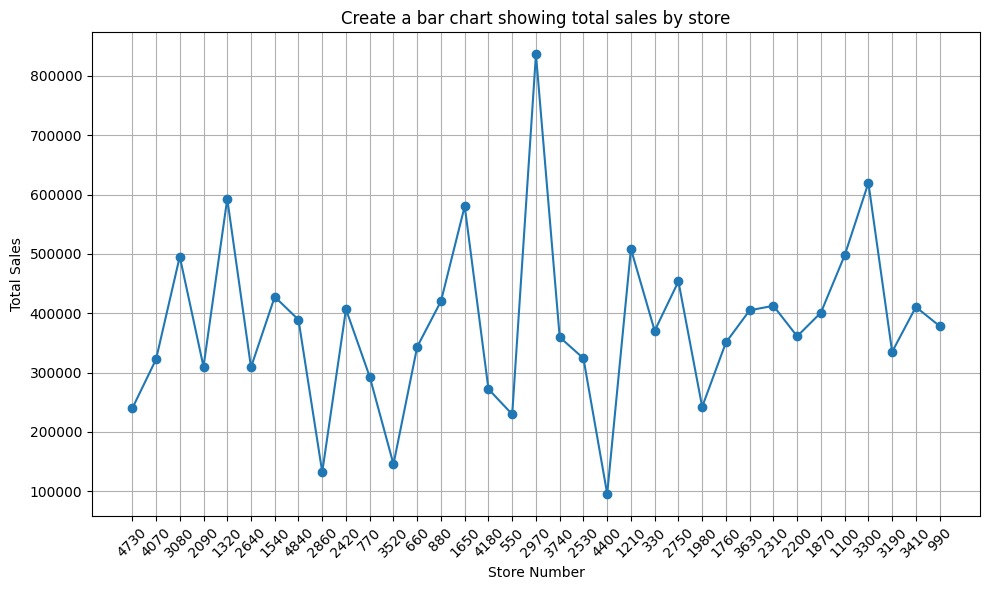

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


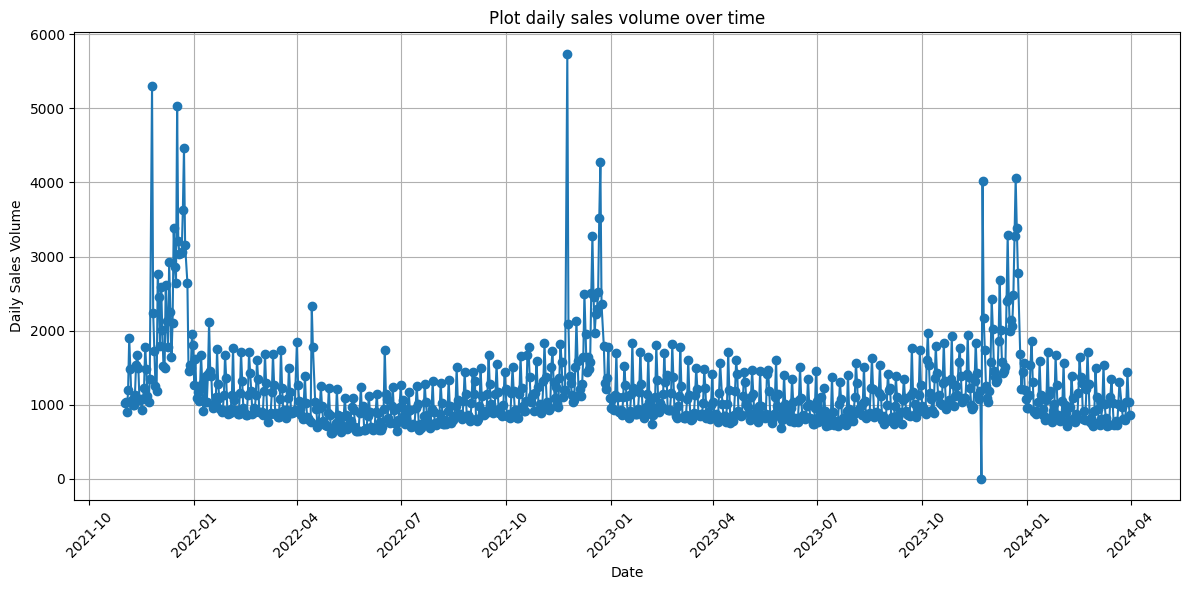


🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNg==/compare?experimentId=RXhwZXJpbWVudDoxNw==

Experiment Summary (05/21/25 06:44 PM +0000)
--------------------------------------------
| evaluator             |   n |   n_scores |   avg_score |   n_labels | top_2_labels   |
|:----------------------|----:|-----------:|------------:|-----------:|:---------------|
| code_is_runnable      |   4 |          2 |           1 |          2 | {'True': 2}    |
| evaluate_chart_config |   4 |          2 |           0 |          2 | {'False': 2}   |

Tasks Summary (05/21/25 06:44 PM +0000)
---------------------------------------
|   n_examples |   n_runs |   n_errors |
|-------------:|---------:|-----------:|
|            4 |        2 |          0 |


In [ ]:
experiment = run_experiment(
    dataset,
    run_code_generation,
    evaluators=[code_is_runnable, evaluate_chart_config],
    experiment_name="Code Generation Eval",
    experiment_description="Evaluating the code generation step of the agent",
)

## Ewaluacja: obraz całości

In [ ]:
# IRL: human annotated

convergence_questions = [
    "What was the average quantity sold per transaction?",
    "What is the mean number of items per sale?",
    "Calculate the typical quantity per transaction",
    "Show me the average number of units sold in each transaction",
    "What's the mean transaction size in terms of quantity?",
    # "On average, how many items were purchased per transaction?",
    # "What is the average basket size per sale?",
    # "Calculate the mean number of products per purchase",
    # "What's the typical number of units per order?",
    # "Find the average quantity of items in each transaction",
    # "What is the average number of products bought per purchase?",
    # "Tell me the mean quantity of items in a typical transaction",
    # "How many items does a customer buy on average per transaction?",
    # "What's the usual number of units in each sale?",
    # "Calculate the average basket quantity per order",
    # "What is the typical amount of products per transaction?",
    # "Show the mean number of items customers purchase per visit",
    # "What's the average quantity of units per shopping trip?",
    # "How many products do customers typically buy in one transaction?",
    # "What is the standard basket size in terms of quantity?",
]

convergence_df = pd.DataFrame({"question": convergence_questions})

dataset = px_client.upload_dataset(
    dataframe=convergence_df,
    dataset_name="convergence_questions2",
    input_keys=["question"],
)

📤 Uploading dataset...
💾 Examples uploaded: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/examples
🗄️ Dataset version ID: RGF0YXNldFZlcnNpb246MTc=


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


In [ ]:
def format_message_steps(messages):
    """
    Convert a list of message objects into a readable format that shows the steps taken.

    Args:
        messages (list): A list of message objects containing role, content, tool calls, etc.

    Returns:
        str: A readable string showing the steps taken.
    """
    steps = []
    for message in messages:
        role = message.get("role")
        if role == "user":
            steps.append(f"User: {message.get('content')}")
        elif role == "system":
            steps.append("System: Provided context")
        elif role == "assistant":
            if message.get("tool_calls"):
                for tool_call in message["tool_calls"]:
                    tool_name = tool_call["function"]["name"]
                    steps.append(f"Assistant: Called tool '{tool_name}'")
            else:
                steps.append(f"Assistant: {message.get('content')}")
        elif role == "tool":
            steps.append(f"Tool response: {message.get('content')}")

    return "\n".join(steps)

In [ ]:
def run_agent_and_track_path(example: Example) -> str:
    print("Starting main span with messages:", example.input.get("question"))
    messages = [{"role": "user", "content": example.input.get("question")}]
    ret = run_agent_messages(messages)
    return {"path_length": len(ret), "messages": format_message_steps(ret)}


def run_agent_messages(messages):
    print("Running agent with messages:", messages)
    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
        print("Converted string message to list format")

    # Check and add system prompt if needed
    if not any(
        isinstance(message, dict) and message.get("role") == "system"
        for message in messages
    ):
        system_prompt = {
            "role": "system",
            "content": "You are a helpful assistant that can answer questions about the Store Sales Price Elasticity Promotions dataset.",
        }
        messages.append(system_prompt)
        print("Added system prompt to messages")

    while True:
        # Router call span
        print("Starting router")

        response = client.chat.completions.create(
            model=CFG.model,
            messages=messages,
            tools=tools,
        )

        messages.append(response.choices[0].message.model_dump())
        tool_calls = response.choices[0].message.tool_calls
        print("Received response with tool calls:", bool(tool_calls))

        if tool_calls:
            # Tool calls span
            print("Processing tool calls")
            tool_calls = response.choices[0].message.tool_calls
            messages = handle_tool_calls(tool_calls, messages)
        else:
            print("No tool calls, returning final response")
            return messages

In [ ]:
experiment = run_experiment(
    dataset,
    run_agent_and_track_path,
    experiment_name="Convergence Eval",
    experiment_description="Evaluating the convergence of the agent",
)

🧪 Experiment started.
📺 View dataset experiments: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/experiments
🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/compare?experimentId=RXhwZXJpbWVudDoxOA==


running tasks |          | 0/5 (0.0%) | ⏳ 00:00<? | ?it/s

Starting main span with messages: What was the average quantity sold per transaction?
Running agent with messages: [{'role': 'user', 'content': 'What was the average quantity sold per transaction?'}]
Added system prompt to messages
Starting router
Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router
Received response with tool calls: False
No tool calls, returning final response
Starting main span with messages: What is the mean number of items per sale?
Running agent with messages: [{'role': 'user', 'content': 'What is the mean number of items per sale?'}]
Added system prompt to messages
Starting router


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router
Received response with tool calls: False
No tool calls, returning final response
Starting main span with messages: Calculate the typical quantity per transaction
Running agent with messages: [{'role': 'user', 'content': 'Calculate the typical quantity per transaction'}]
Added system prompt to messages
Starting router


...

Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/phoenix/experiments/functions.py", line 317, in async_run_experiment
    _output = task(*bound_task_args.args, **bound_task_args.kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-46-41242246f14b>", line 4, in run_agent_and_track_path
    ret = run_agent_messages(messages)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-46-41242246f14b>", line 29, in run_agent_messages
    response = client.chat.completions.create(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/openai/_utils/_utils.py", line 279, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router
Received response with tool calls: False
No tool calls, returning final response


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


✅ Task runs completed.

🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/compare?experimentId=RXhwZXJpbWVudDoxOA==

Tasks Summary (05/21/25 06:50 PM +0000)
---------------------------------------
|   n_examples |   n_runs |   n_errors | top_error                                                                                            |
|-------------:|---------:|-----------:|:-----------------------------------------------------------------------------------------------------|
|            5 |        5 |          1 | BadRequestError('Error code: 400 - {\'error\': {\'message\': "This model\'s maximum context length i |


In [ ]:
experiment.as_dataframe()

,error,output,input,example_id
run_id,,,,
RXhwZXJpbWVudFJ1bjoyMDc=,None,"{'path_length': 5, 'messages': 'User: What was...",{'question': 'What was the average quantity so...,RGF0YXNldEV4YW1wbGU6MjQ3
RXhwZXJpbWVudFJ1bjoyMDg=,None,"{'path_length': 5, 'messages': 'User: What is ...",{'question': 'What is the mean number of items...,RGF0YXNldEV4YW1wbGU6MjQ4
RXhwZXJpbWVudFJ1bjoyMDk=,None,"{'path_length': 5, 'messages': 'User: Calculat...",{'question': 'Calculate the typical quantity p...,RGF0YXNldEV4YW1wbGU6MjQ5
RXhwZXJpbWVudFJ1bjoyMTA=,BadRequestError('Error code: 400 - {\'error\':...,None,{'question': 'Show me the average number of un...,RGF0YXNldEV4YW1wbGU6MjUw
RXhwZXJpbWVudFJ1bjoyMTE=,None,"{'path_length': 5, 'messages': 'User: What's t...",{'question': 'What's the mean transaction size...,RGF0YXNldEV4YW1wbGU6MjUx


In [ ]:
outputs = experiment.as_dataframe()["output"].to_dict().values()
optimal_path_length = min(
    output.get("path_length")
    for output in outputs
    if output and output.get("path_length") is not None
)
print(f"The optimal path length is {optimal_path_length}")

The optimal path length is 5


In [ ]:
@create_evaluator(name="Convergence Eval", kind="CODE")
def evaluate_path_length(output: str) -> float:
    if output and output.get("path_length"):
        return optimal_path_length / float(output.get("path_length"))
    else:
        return 0

In [ ]:
experiment = evaluate_experiment(experiment, evaluators=[evaluate_path_length])

🧠 Evaluation started.


running experiment evaluations |          | 0/5 (0.0%) | ⏳ 00:00<? | ?it/s

/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(



🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/compare?experimentId=RXhwZXJpbWVudDoxOA==

Experiment Summary (05/21/25 06:50 PM +0000)
--------------------------------------------
| evaluator        |   n |   n_scores |   avg_score |
|:-----------------|----:|-----------:|------------:|
| Convergence Eval |   5 |          5 |         0.8 |

Tasks Summary (05/21/25 06:50 PM +0000)
---------------------------------------
|   n_examples |   n_runs |   n_errors | top_error                                                                                            |
|-------------:|---------:|-----------:|:-----------------------------------------------------------------------------------------------------|
|            5 |        5 |          1 | BadRequestError('Error code: 400 - {\'error\': {\'message\': "This model\'s maximum context length i |


# BONUS TRACK: wszystko wszędzie naraz

Najpierw upgrade agenta -> zbiera wszystko

In [ ]:
def process_messages(messages):
    tool_calls = []
    tool_responses = []
    final_output = None

    for i, message in enumerate(messages):
        # Extract tool calls
        if "tool_calls" in message and message["tool_calls"]:
            for tool_call in message["tool_calls"]:
                tool_name = tool_call["function"]["name"]
                tool_input = tool_call["function"]["arguments"]
                tool_calls.append(tool_name)

                # Prepare tool response structure with tool name and input
                tool_responses.append(
                    {
                        "tool_name": tool_name,
                        "tool_input": tool_input,
                        "tool_response": None,
                    }
                )

        # Extract tool responses
        if message["role"] == "tool" and "tool_call_id" in message:
            for tool_response in tool_responses:
                if message["tool_call_id"] in message.values():
                    tool_response["tool_response"] = message["content"]

        # Extract final output
        if (
            message["role"] == "assistant"
            and not message.get("tool_calls")
            and not message.get("function_call")
        ):
            final_output = message["content"]

    result = {
        "tool_calls": tool_calls,
        "tool_responses": tool_responses,
        "final_output": final_output,
        "unchanged_messages": messages,
        "path_length": len(messages),
    }

    return result

In [ ]:
def run_agent_and_track_path_combined(example: Example) -> str:
    print("Starting main span with messages:", example.input.get("question"))
    messages = [{"role": "user", "content": example.input.get("question")}]
    ret = run_agent_messages_combined(messages)
    return process_messages(ret)


def run_agent_messages_combined(messages):
    print("Running agent with messages:", messages)
    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
        print("Converted string message to list format")

    # Check and add system prompt if needed
    if not any(
        isinstance(message, dict) and message.get("role") == "system"
        for message in messages
    ):
        system_prompt = {
            "role": "system",
            "content": "You are a helpful assistant that can answer questions about the Store Sales Price Elasticity Promotions dataset.",
        }
        messages.append(system_prompt)
        print("Added system prompt to messages")

    while True:
        # Router call span
        print("Starting router")

        response = client.chat.completions.create(
            model=CFG.model,
            messages=messages,
            tools=tools,
        )

        messages.append(response.choices[0].message.model_dump())
        tool_calls = response.choices[0].message.tool_calls
        print("Received response with tool calls:", bool(tool_calls))

        if tool_calls:
            # Tool calls span
            print("Processing tool calls")
            tool_calls = response.choices[0].message.tool_calls
            messages = handle_tool_calls(tool_calls, messages)
        else:
            print("No tool calls, returning final response")
            return messages

In [ ]:
generate_sql_query(
    "What was the most popular product SKU?", store_sales_df.columns, "sales"
)

'```sql\nSELECT SKU_Coded, SUM(Qty_Sold) AS Total_Qty_Sold\nFROM sales\nGROUP BY SKU_Coded\nORDER BY Total_Qty_Sold DESC\nLIMIT 1;\n```'

In [ ]:
overall_experiment_questions = [
    {
        "question": "What was the most popular product SKU?",
        "sql_result": "   SKU_Coded  Total_Qty_Sold 0    6200700         52262.0",
    },
    {
        "question": "What was the total revenue across all stores?",
        "sql_result": "   Total_Revenue 0   1.327264e+07",
    },
    {
        "question": "Which store had the highest sales volume?",
        "sql_result": "   Store_Number  Total_Sales_Volume 0          2970             59322.0",
    },
    {
        "question": "Create a bar chart showing total sales by store",
        "sql_result": "    Store_Number    Total_Sales 0            880  420302.088397 1           1650  580443.007953 2           4180  272208.118542 3            550  229727.498752 4           1100  497509.528013 5           3300  619660.167018 6           3190  335035.018792 7           2970  836341.327191 8           3740  359729.808228 9           2530  324046.518720 10          4400   95745.620250 11          1210  508393.767785 12           330  370503.687331 13          2750  453664.808068 14          1980  242290.828499 15          1760  350747.617798 16          3410  410567.848126 17           990  378433.018639 18          4730  239711.708869 19          4070  322307.968330 20          3080  495458.238811 21          2090  309996.247965 22          1320  592832.067579 23          2640  308990.318559 24          1540  427777.427815 25          4840  389056.668316 26          2860  132320.519487 27          2420  406715.767402 28           770  292968.918642 29          3520  145701.079372 30           660  343594.978075 31          3630  405034.547846 32          2310  412579.388504 33          2200  361173.288199 34          1870  401070.997685",
    },
    {
        "question": "What percentage of items were sold on promotion?",
        "sql_result": "   Promotion_Percentage 0              0.625596",
    },
    {
        "question": "What was the average transaction value?",
        "sql_result": "   Average_Transaction_Value 0                  19.018132",
    },
    {
        "question": "Create a line chart showing sales in 2021",
        "sql_result": "  sale_month  total_quantity_sold  total_sales_value 0 2021-11-01              43056.0      499984.428193 1 2021-12-01              75724.0      910982.118423",
    },
]

overall_experiment_questions[0]["sql_generated"] = generate_sql_query(
    overall_experiment_questions[0]["question"], store_sales_df.columns, "sales"
)
overall_experiment_questions[1]["sql_generated"] = generate_sql_query(
    overall_experiment_questions[1]["question"], store_sales_df.columns, "sales"
)
overall_experiment_questions[2]["sql_generated"] = generate_sql_query(
    overall_experiment_questions[2]["question"], store_sales_df.columns, "sales"
)
overall_experiment_questions[3]["sql_generated"] = generate_sql_query(
    overall_experiment_questions[3]["question"], store_sales_df.columns, "sales"
)
overall_experiment_questions[4]["sql_generated"] = generate_sql_query(
    overall_experiment_questions[4]["question"], store_sales_df.columns, "sales"
)
overall_experiment_questions[5]["sql_generated"] = generate_sql_query(
    overall_experiment_questions[5]["question"], store_sales_df.columns, "sales"
)
overall_experiment_questions[6]["sql_generated"] = generate_sql_query(
    overall_experiment_questions[6]["question"], store_sales_df.columns, "sales"
)

print(overall_experiment_questions[6])

{'question': 'Create a line chart showing sales in 2021', 'sql_result': '  sale_month  total_quantity_sold  total_sales_value 0 2021-11-01              43056.0      499984.428193 1 2021-12-01              75724.0      910982.118423', 'sql_generated': '```sql\nSELECT \n    MONTH(Sold_Date) AS Month, \n    SUM(Total_Sale_Value) AS Total_Sales\nFROM \n    sales\nWHERE \n    YEAR(Sold_Date) = 2021\nGROUP BY \n    MONTH(Sold_Date)\nORDER BY \n    Month;\n```'}


In [ ]:
[
    {
        "question": "What was the most popular product SKU?",
        "sql_result": "   SKU_Coded  Total_Qty_Sold 0    6200700         52262.0",
        "sql_generated": "```sql\nSELECT SKU_Coded, SUM(Qty_Sold) AS Total_Qty_Sold\nFROM sales\nGROUP BY SKU_Coded\nORDER BY Total_Qty_Sold DESC\nLIMIT 1;\n```",
    },
    {
        "question": "What was the total revenue across all stores?",
        "sql_result": "   Total_Revenue 0   1.327264e+07",
        "sql_generated": "```sql\nSELECT SUM(Total_Sale_Value) AS Total_Revenue\nFROM sales;\n```",
    },
    {
        "question": "Which store had the highest sales volume?",
        "sql_result": "   Store_Number  Total_Sales_Volume 0          2970             59322.0",
        "sql_generated": "```sql\nSELECT Store_Number, SUM(Total_Sale_Value) AS Total_Sales_Volume\nFROM sales\nGROUP BY Store_Number\nORDER BY Total_Sales_Volume DESC\nLIMIT 1;\n```",
    },
    {
        "question": "Create a bar chart showing total sales by store",
        "sql_result": "    Store_Number    Total_Sales 0            880  420302.088397 1           1650  580443.007953 2           4180  272208.118542 3            550  229727.498752 4           1100  497509.528013 5           3300  619660.167018 6           3190  335035.018792 7           2970  836341.327191 8           3740  359729.808228 9           2530  324046.518720 10          4400   95745.620250 11          1210  508393.767785 12           330  370503.687331 13          2750  453664.808068 14          1980  242290.828499 15          1760  350747.617798 16          3410  410567.848126 17           990  378433.018639 18          4730  239711.708869 19          4070  322307.968330 20          3080  495458.238811 21          2090  309996.247965 22          1320  592832.067579 23          2640  308990.318559 24          1540  427777.427815 25          4840  389056.668316 26          2860  132320.519487 27          2420  406715.767402 28           770  292968.918642 29          3520  145701.079372 30           660  343594.978075 31          3630  405034.547846 32          2310  412579.388504 33          2200  361173.288199 34          1870  401070.997685",
        "sql_generated": "```sql\nSELECT Store_Number, SUM(Total_Sale_Value) AS Total_Sales\nFROM sales\nGROUP BY Store_Number;\n```",
    },
    {
        "question": "What percentage of items were sold on promotion?",
        "sql_result": "   Promotion_Percentage 0              0.625596",
        "sql_generated": "```sql\nSELECT \n    (SUM(CASE WHEN On_Promo = 'Yes' THEN 1 ELSE 0 END) * 100.0) / COUNT(*) AS Promotion_Percentage\nFROM \n    sales;\n```",
    },
    {
        "question": "What was the average transaction value?",
        "sql_result": "   Average_Transaction_Value 0                  19.018132",
        "sql_generated": "```sql\nSELECT AVG(Total_Sale_Value) AS Average_Transaction_Value\nFROM sales;\n```",
    },
    {
        "question": "Create a line chart showing sales in 2021",
        "sql_result": "  sale_month  total_quantity_sold  total_sales_value 0 2021-11-01              43056.0      499984.428193 1 2021-12-01              75724.0      910982.118423",
        "sql_generated": "```sql\nSELECT MONTH(Sold_Date) AS Month, SUM(Total_Sale_Value) AS Total_Sales\nFROM sales\nWHERE YEAR(Sold_Date) = 2021\nGROUP BY MONTH(Sold_Date)\nORDER BY MONTH(Sold_Date);\n```",
    },
]

[{'question': 'What was the most popular product SKU?',
  'sql_result': '   SKU_Coded  Total_Qty_Sold 0    6200700         52262.0',
  'sql_generated': '```sql\nSELECT SKU_Coded, SUM(Qty_Sold) AS Total_Qty_Sold\nFROM sales\nGROUP BY SKU_Coded\nORDER BY Total_Qty_Sold DESC\nLIMIT 1;\n```'},
 {'question': 'What was the total revenue across all stores?',
  'sql_result': '   Total_Revenue 0   1.327264e+07',
  'sql_generated': '```sql\nSELECT SUM(Total_Sale_Value) AS Total_Revenue\nFROM sales;\n```'},
 {'question': 'Which store had the highest sales volume?',
  'sql_result': '   Store_Number  Total_Sales_Volume 0          2970             59322.0',
  'sql_generated': '```sql\nSELECT Store_Number, SUM(Total_Sale_Value) AS Total_Sales_Volume\nFROM sales\nGROUP BY Store_Number\nORDER BY Total_Sales_Volume DESC\nLIMIT 1;\n```'},
 {'question': 'Create a bar chart showing total sales by store',
  'sql_result': '    Store_Number    Total_Sales 0            880  420302.088397 1           1650  5804

In [ ]:
CLARITY_LLM_JUDGE_PROMPT = """
In this task, you will be presented with a query and an answer. Your objective is to evaluate the clarity
of the answer in addressing the query. A clear response is one that is precise, coherent, and directly
addresses the query without introducing unnecessary complexity or ambiguity. An unclear response is one
that is vague, disorganized, or difficult to understand, even if it may be factually correct.

Your response should be a single word: either "clear" or "unclear," and it should not include any other
text or characters. "clear" indicates that the answer is well-structured, easy to understand, and
appropriately addresses the query. "unclear" indicates that the answer is ambiguous, poorly organized, or
not effectively communicated. Please carefully consider the query and answer before determining your
response.

After analyzing the query and the answer, you must write a detailed explanation of your reasoning to
justify why you chose either "clear" or "unclear." Avoid stating the final label at the beginning of your
explanation. Your reasoning should include specific points about how the answer does or does not meet the
criteria for clarity.

[BEGIN DATA]
Query: {query}
Answer: {response}
[END DATA]
Please analyze the data carefully and provide an explanation followed by your response.

EXPLANATION: Provide your reasoning step by step, evaluating the clarity of the answer based on the query.
LABEL: "clear" or "unclear"
"""

ENTITY_CORRECTNESS_LLM_JUDGE_PROMPT = """
In this task, you will be presented with a query and an answer. Your objective is to determine whether all
the entities mentioned in the answer are correctly identified and accurately match those in the query. An
entity refers to any specific person, place, organization, date, or other proper noun. Your evaluation
should focus on whether the entities in the answer are correctly named and appropriately associated with
the context in the query.

Your response should be a single word: either "correct" or "incorrect," and it should not include any
other text or characters. "correct" indicates that all entities mentioned in the answer match those in the
query and are properly identified. "incorrect" indicates that the answer contains errors or mismatches in
the entities referenced compared to the query.

After analyzing the query and the answer, you must write a detailed explanation of your reasoning to
justify why you chose either "correct" or "incorrect." Avoid stating the final label at the beginning of
your explanation. Your reasoning should include specific points about how the entities in the answer do or
do not match the entities in the query.

[BEGIN DATA]
Query: {query}
Answer: {response}
[END DATA]
Please analyze the data carefully and provide an explanation followed by your response.

EXPLANATION: Provide your reasoning step by step, evaluating whether the entities in the answer are
correct and consistent with the query.
LABEL: "correct" or "incorrect"
"""

In [ ]:
def function_calling_eval(input: str, output: str) -> float:
    function_calls = output.get("tool_calls")
    if function_calls:
        eval_df = pd.DataFrame(
            {
                "question": [input.get("question")] * len(function_calls),
                "tool_call": function_calls,
            }
        )

        tool_call_eval = llm_classify(
            dataframe=eval_df,
            template=str(TOOL_CALLING_PROMPT_TEMPLATE).replace(
                "{tool_definitions}",
                json.dumps(tools).replace("{", '"').replace("}", '"'),
            ),
            rails=["correct", "incorrect"],
            model=eval_model,
            provide_explanation=True,
        )

        tool_call_eval["score"] = tool_call_eval.apply(
            lambda x: 1 if x["label"] == "correct" else 0, axis=1
        )
        return tool_call_eval["score"].mean()
    else:
        return 0

In [ ]:
def code_is_runnable(output: str) -> bool:
    """Check if the code is runnable"""
    generated_code = output.get("tool_responses")
    if not generated_code:
        return True

    # Find first lookup_sales_data response
    generated_code = next(
        (r for r in generated_code if r.get("tool_name") == "generate_visualization"),
        None,
    )
    if not generated_code:
        return True

    # Get the first response
    generated_code = generated_code.get("tool_response", "")
    generated_code = generated_code.strip()
    generated_code = generated_code.replace("```python", "").replace("```", "")
    try:
        exec(generated_code)
        return True
    except Exception:
        return False

In [ ]:
def evaluate_sql_result(output, expected) -> bool:
    sql_result = output.get("tool_responses")
    if not sql_result:
        return True

    # Find first lookup_sales_data response
    sql_result = next(
        (r for r in sql_result if r.get("tool_name") == "lookup_sales_data"), None
    )
    if not sql_result:
        return True

    # Get the first response
    sql_result = sql_result.get("tool_response", "")

    # Extract just the numbers from both strings
    result_nums = "".join(filter(str.isdigit, sql_result))
    expected_nums = "".join(filter(str.isdigit, expected.get("sql_result")))
    return result_nums == expected_nums


In [ ]:
def evaluate_clarity(output: str, input: str) -> bool:
    df = pd.DataFrame(
        {"query": [input.get("question")], "response": [output.get("final_output")]}
    )
    response = llm_classify(
        dataframe=df,
        template=CLARITY_LLM_JUDGE_PROMPT,
        rails=["clear", "unclear"],
        model=eval_model,
        provide_explanation=True,
    )
    return response["label"] == "clear"


In [ ]:
def evaluate_entity_correctness(output: str, input: str) -> bool:
    df = pd.DataFrame(
        {"query": [input.get("question")], "response": [output.get("final_output")]}
    )
    response = llm_classify(
        dataframe=df,
        template=ENTITY_CORRECTNESS_LLM_JUDGE_PROMPT,
        rails=["correct", "incorrect"],
        model=eval_model,
        provide_explanation=True,
    )
    return response["label"] == "correct"

In [ ]:
def run_overall_experiment(example: Example) -> str:
    with suppress_tracing():
        return run_agent_and_track_path_combined(example)


experiment = run_experiment(
    dataset,
    run_overall_experiment,
    evaluators=[
        function_calling_eval,
        evaluate_sql_result,
        evaluate_clarity,
        evaluate_entity_correctness,
        code_is_runnable,
    ],
    experiment_name="Overall Experiment",
    experiment_description="Evaluating the overall experiment",
)

🧪 Experiment started.
📺 View dataset experiments: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/experiments
🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/compare?experimentId=RXhwZXJpbWVudDoxOQ==


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


running tasks |          | 0/5 (0.0%) | ⏳ 00:00<? | ?it/s

Starting main span with messages: What was the average quantity sold per transaction?
Running agent with messages: [{'role': 'user', 'content': 'What was the average quantity sold per transaction?'}]
Added system prompt to messages
Starting router
Received response with tool calls: True
Processing tool calls
Index(['Store_Number', 'SKU_Coded', 'Product_Class_Code', 'Sold_Date',
       'Qty_Sold', 'Total_Sale_Value', 'On_Promo'],
      dtype='object')
sales
Starting router
Received response with tool calls: False
No tool calls, returning final response
Starting main span with messages: What is the mean number of items per sale?
Running agent with messages: [{'role': 'user', 'content': 'What is the mean number of items per sale?'}]
Added system prompt to messages
Starting router


/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(


...

llm_classify |          | 0/1 (0.0%) | ⏳ 00:00<? | ?it/s

Retries exhausted after 1 attempts: Client error '422 unknown' for url 'https://app.phoenix.arize.com/v1/experiment_evaluations'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/422


llm_classify |          | 0/1 (0.0%) | ⏳ 00:00<? | ?it/s

/usr/local/lib/python3.11/dist-packages/phoenix/experiments/evaluators/utils.py:229: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return EvaluationResult(score=float(result))
/usr/local/lib/python3.11/dist-packages/phoenix/utilities/client.py:51: UserWarning: ⚠️⚠️ The Phoenix server (8.27.0) and client (10.0.0) versions are severely mismatched. Upgrade  either the client or server to ensure API compatibility ⚠️⚠️
  warnings.warn(



🔗 View this experiment: https://app.phoenix.arize.com/datasets/RGF0YXNldDoxNw==/compare?experimentId=RXhwZXJpbWVudDoxOQ==

Experiment Summary (05/21/25 06:51 PM +0000)
--------------------------------------------
| evaluator                   |   n |   n_scores |   avg_score |   n_labels | top_2_labels   |
|:----------------------------|----:|-----------:|------------:|-----------:|:---------------|
| code_is_runnable            |   5 |          4 |        1    |          4 | {'True': 4}    |
| evaluate_clarity            |   5 |          4 |        1    |          0 |                |
| evaluate_entity_correctness |   5 |          4 |        1    |          0 |                |
| evaluate_sql_result         |   5 |        nan |      nan    |        nan | nan            |
| function_calling_eval       |   5 |          4 |        0.75 |          0 |                |

Tasks Summary (05/21/25 06:51 PM +0000)
---------------------------------------
|   n_examples |   n_runs |   n_errors |